# Import librerie e setup variabili

Download dei dati da Yahoo Finance, con definizione di un intervallo di date e di una lista di titoli. I dati vengono organizzati in una lista di tuple (ticker, dataframe) per facilitare l'elaborazione successiva.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import datetime as dt
from IPython.display import display
from scipy import stats

start_date = dt.datetime(2016, 3, 31)
end_date = dt.datetime(2026, 3, 31)
stocks = ['MSFT', 'NVDA', 'TSLA', 'GM', 'XOM', 'NEE']
stock_list = []

data = yf.download(stocks, start=start_date, end=end_date)
for t in data.columns.get_level_values('Ticker').unique():
    ticker = data.xs(t, axis=1, level = 'Ticker', drop_level=True)
    stock_list.append((t, ticker))

data.head()

[*********************100%***********************]  6 of 6 completed


Price           Close                                                        \
Ticker             GM       MSFT        NEE      NVDA       TSLA        XOM   
Date                                                                          
2016-03-31  25.543209  48.491241  22.920946  0.872227  15.318000  53.705719   
2016-04-01  24.763012  48.789764  22.992609  0.884957  15.839333  53.300949   
2016-04-04  24.299770  48.666843  22.994551  0.876388  16.466000  53.429432   
2016-04-05  24.055964  47.902992  22.535507  0.875164  17.031334  52.819080   
2016-04-06  24.332283  48.394669  22.605236  0.876388  17.694668  53.525814   

Price            High                                  ...       Open  \
Ticker             GM       MSFT        NEE      NVDA  ...        NEE   
Date                                                   ...              
2016-03-31  25.673241  48.807317  23.010044  0.881284  ...  22.901578   
2016-04-01  25.356285  48.824885  23.046841  0.885446  ...  22.872522   
2016-04-04  24.771137  48.868780  23.083647  0.896952  ...  23.054593   
2016-04-05  24.161614  48.552701  23.029410  0.883243  ...  22.913198   
2016-04-06  24.340410  48.464909  22.611046  0.876878  ...  22.529698   

Price                                         Volume                     \
Ticker          NVDA       TSLA        XOM        GM      MSFT      NEE   
Date                                                                      
2016-03-31  0.879326  15.289333  54.014116  10209000  26360500  8025600   
2016-04-01  0.866841  16.322001  52.941156  17421700  24399200  8320800   
2016-04-04  0.892300  16.608000  53.365179  12167300  18928800  5239600   
2016-04-05  0.868555  16.033333  53.076077   9101900  19272300  8802800   
2016-04-06  0.864148  16.931334  53.127474   9620300  21188700  6557200   

Price                                       
Ticker           NVDA       TSLA       XOM  
Date                                        
2016-03-31  379884000  120193500  13896900  
2016-04-01  348292000  239962500  12235300  
2016-04-04  393940000  202129500   8050200  
2016-04-05  339568000  149230500  10446800  
2016-04-06  453376000  175582500   9320200  

[5 rows x 30 columns]

## Esportazione dei dati

Esportazione dei dati scaricati da Yahoo Finance in file CSV, uno per ogni titolo.

In [2]:
for t, df in stock_list:
    df.to_csv(f'./data/{t}.csv')

# Presentazione dei dati

Visualizzazione dei primi 5 record di ogni dataframe, insieme al nome del ticker. Visualizzato un grafico del prezzo di chiusura per ogni titolo.

'Ticker: GM'

Price,Close,High,Low,Open,Volume
Date,,,,,
2016-03-31,25.543209,25.673241,25.193747,25.201874,10209000
2016-04-01,24.763012,25.356285,24.641107,25.340031,17421700
2016-04-04,24.299770,24.771137,24.177865,24.706121,12167300
2016-04-05,24.055964,24.161614,23.852788,24.112852,9101900
2016-04-06,24.332283,24.340410,23.812153,24.104726,9620300
2016-04-07,23.909679,24.340412,23.714631,24.259141,12865600
2016-04-08,23.869043,24.185996,23.755264,24.112853,8843500


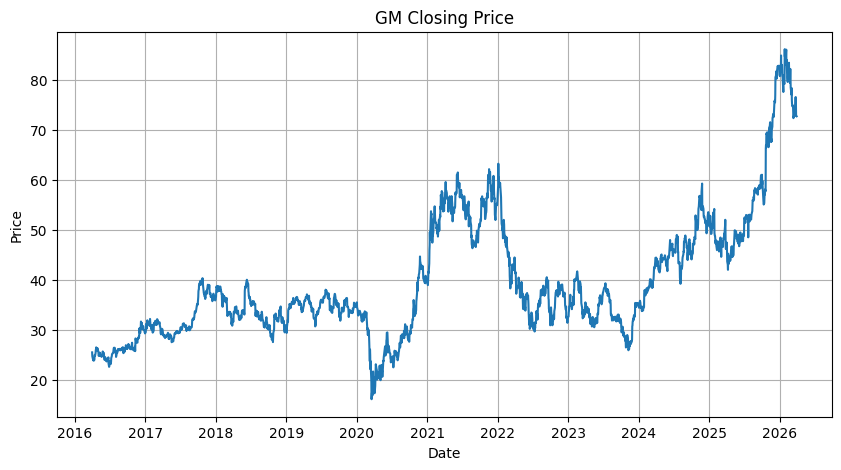

'Ticker: MSFT'

Price,Close,High,Low,Open,Volume
Date,,,,,
2016-03-31,48.491241,48.807317,48.166387,48.245406,26360500
2016-04-01,48.789764,48.824885,47.911777,48.333211,24399200
2016-04-04,48.666843,48.868780,48.289309,48.666843,18928800
2016-04-05,47.902992,48.552701,47.815192,48.456122,19272300
2016-04-06,48.394669,48.464909,47.595700,47.727400,21188700
2016-04-07,47.815193,48.210288,47.613256,48.175168,19225100
2016-04-08,47.780079,48.535149,47.692281,47.999576,22167200


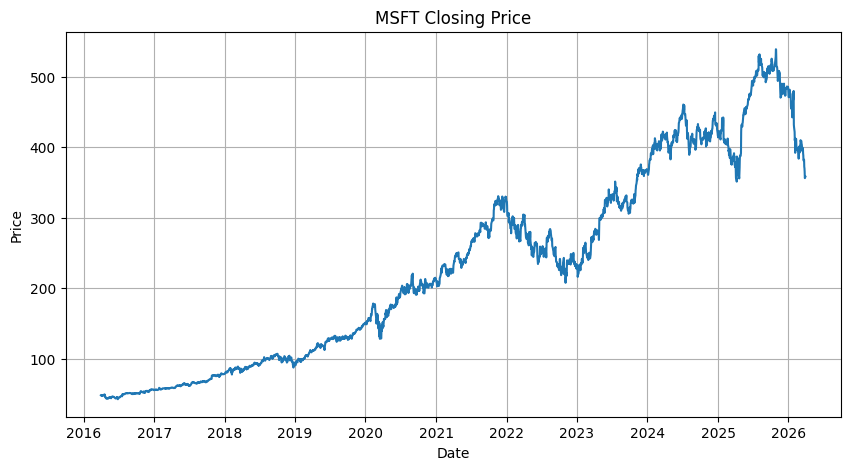

'Ticker: NEE'

Price,Close,High,Low,Open,Volume
Date,,,,,
2016-03-31,22.920946,23.010044,22.826040,22.901578,8025600
2016-04-01,22.992609,23.046841,22.750500,22.872522,8320800
2016-04-04,22.994551,23.083647,22.843475,23.054593,5239600
2016-04-05,22.535507,23.029410,22.496770,22.913198,8802800
2016-04-06,22.605236,22.611046,22.386370,22.529698,6557200
2016-04-07,22.504517,22.721445,22.465778,22.539380,5359600
2016-04-08,22.624607,22.746631,22.465784,22.465784,4268800


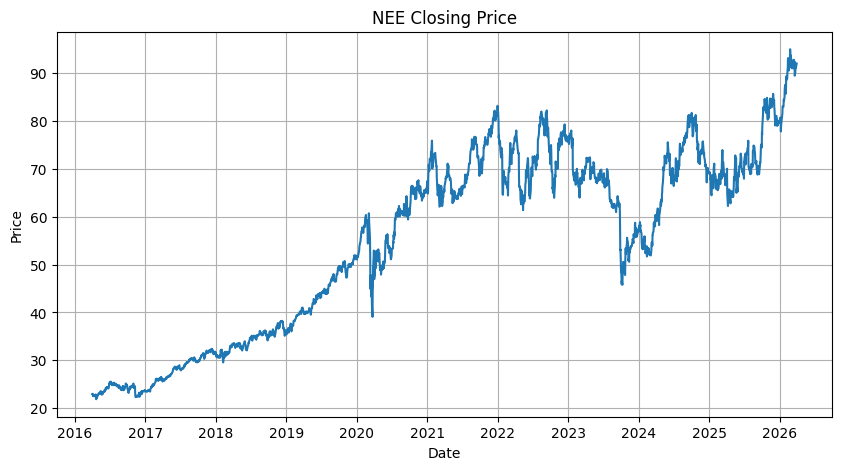

'Ticker: NVDA'

Price,Close,High,Low,Open,Volume
Date,,,,,
2016-03-31,0.872227,0.881284,0.865372,0.879326,379884000
2016-04-01,0.884957,0.885446,0.860232,0.866841,348292000
2016-04-04,0.876388,0.896952,0.872961,0.892300,393940000
2016-04-05,0.875164,0.883243,0.865128,0.868555,339568000
2016-04-06,0.876388,0.876878,0.847747,0.864148,453376000
2016-04-07,0.867331,0.878592,0.863659,0.870758,378104000
2016-04-08,0.872961,0.880061,0.864393,0.874430,255936000


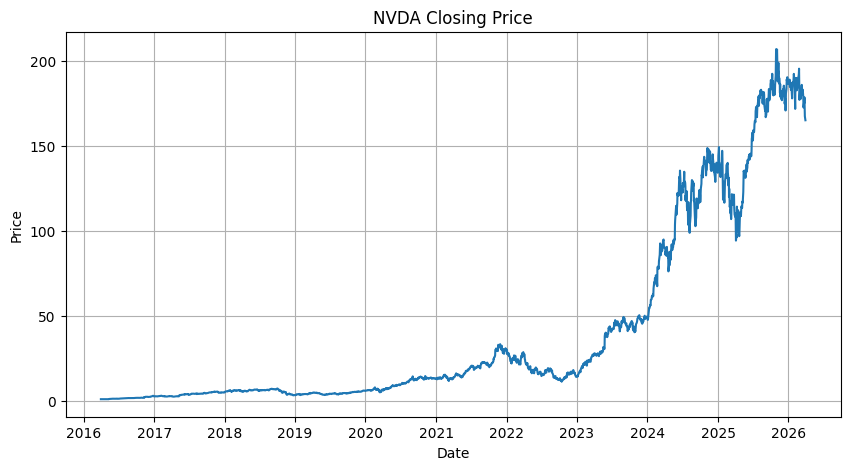

'Ticker: TSLA'

Price,Close,High,Low,Open,Volume
Date,,,,,
2016-03-31,15.318000,15.828000,15.000667,15.289333,120193500
2016-04-01,15.839333,16.526667,15.550000,16.322001,239962500
2016-04-04,16.466000,16.808001,16.242666,16.608000,202129500
2016-04-05,17.031334,17.104000,16.000000,16.033333,149230500
2016-04-06,17.694668,17.849333,16.896667,16.931334,175582500
2016-04-07,17.146667,17.955999,16.967333,17.763332,132843000
2016-04-08,16.671333,17.388000,16.534666,17.366667,110458500


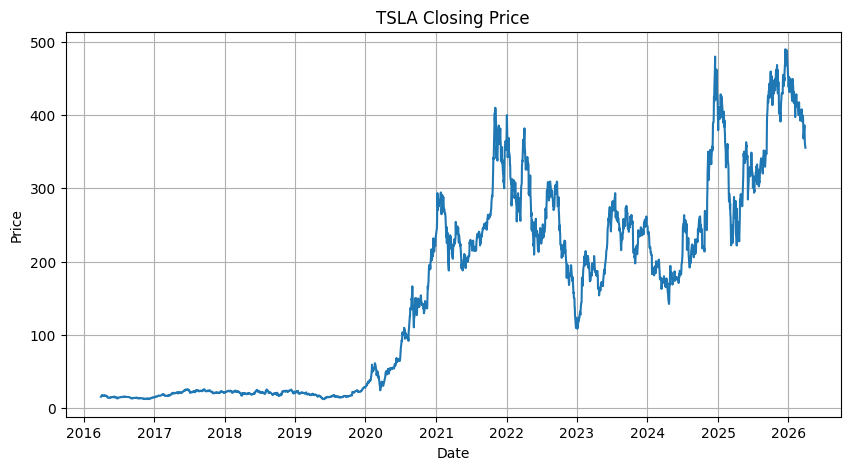

'Ticker: XOM'

Price,Close,High,Low,Open,Volume
Date,,,,,
2016-03-31,53.705719,54.675880,53.705719,54.014116,13896900
2016-04-01,53.300949,53.577220,52.934730,52.941156,12235300
2016-04-04,53.429432,53.904873,53.185283,53.365179,8050200
2016-04-05,52.819080,53.410170,52.677732,53.076077,10446800
2016-04-06,53.525814,53.622188,52.876903,53.127474,9320200
2016-04-07,52.921883,53.435871,52.716286,53.172453,8267100
2016-04-08,53.461555,53.615752,53.230259,53.519382,9376200


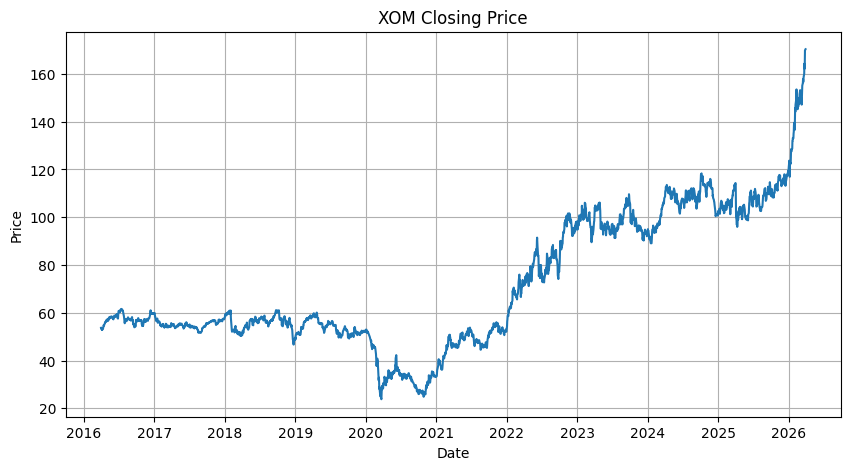

In [3]:
for name, stock in stock_list:
    display(f"Ticker: {name}", stock.head(7))
    plt.figure(figsize=(10, 5))
    plt.plot(stock['Close'])
    plt.title(f'{name} Closing Price')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.grid()
    plt.savefig(f'./relazione/images/{name}_data_presentation.png')
    plt.show()

# Rendimenti

## Calcolo dei rendimenti semplici e logaritmici

Calcolo dei rendimenti semplici e logaritmici per ogni titolo e visualizzazione dei grafici.

Ticker: GM


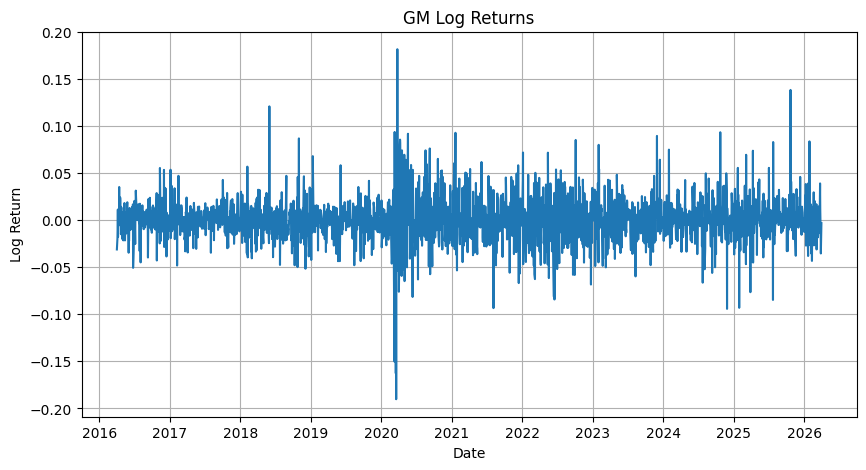

Ticker: MSFT


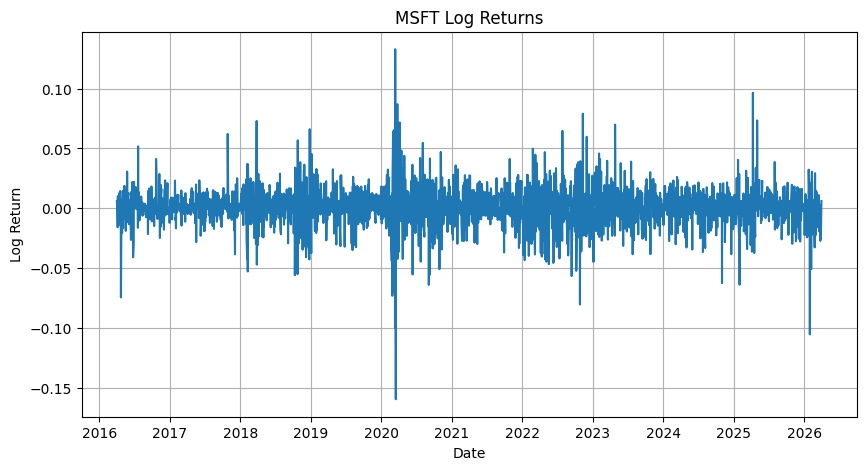

Ticker: NEE


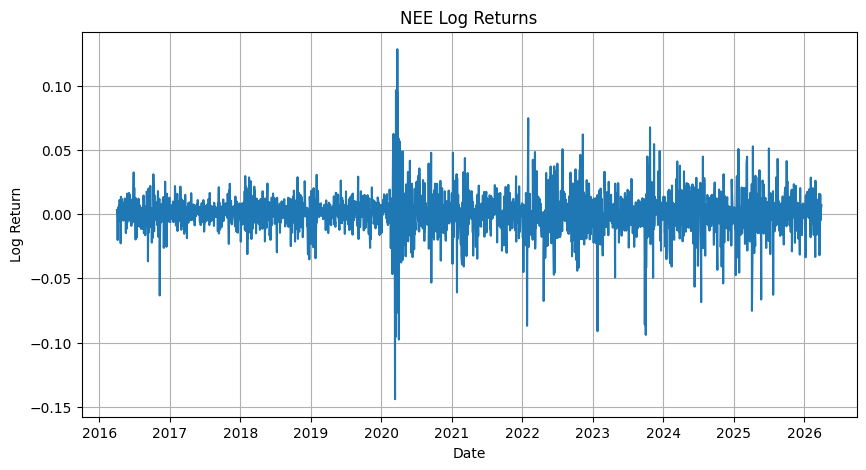

Ticker: NVDA


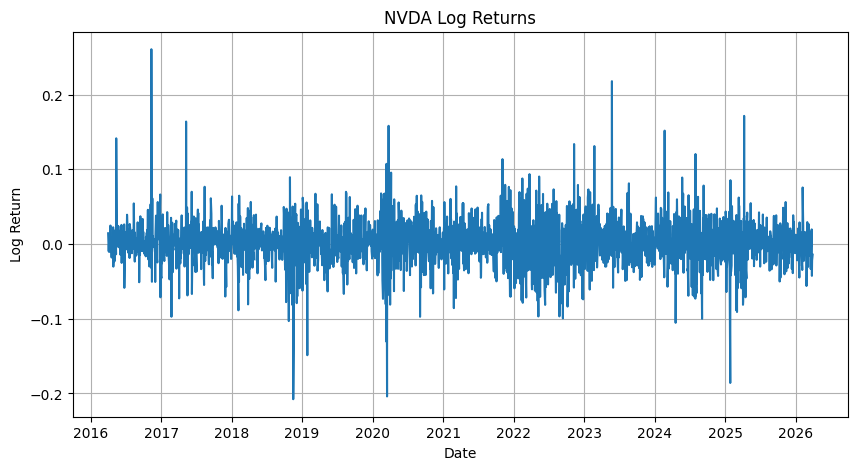

Ticker: TSLA


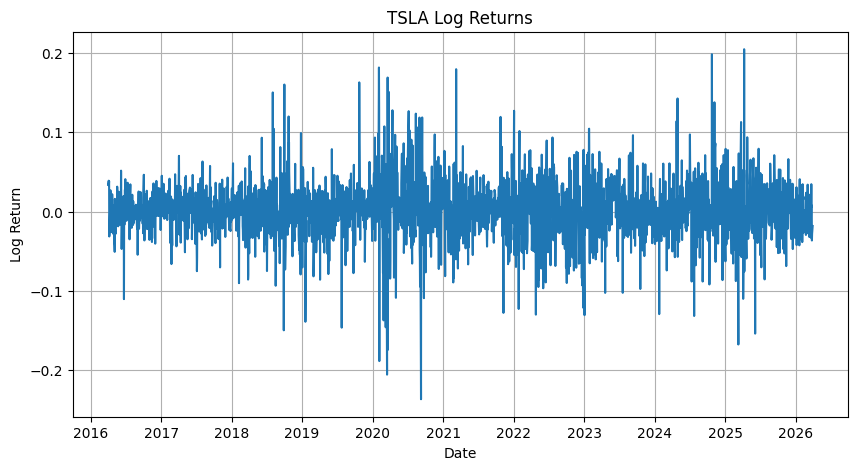

Ticker: XOM


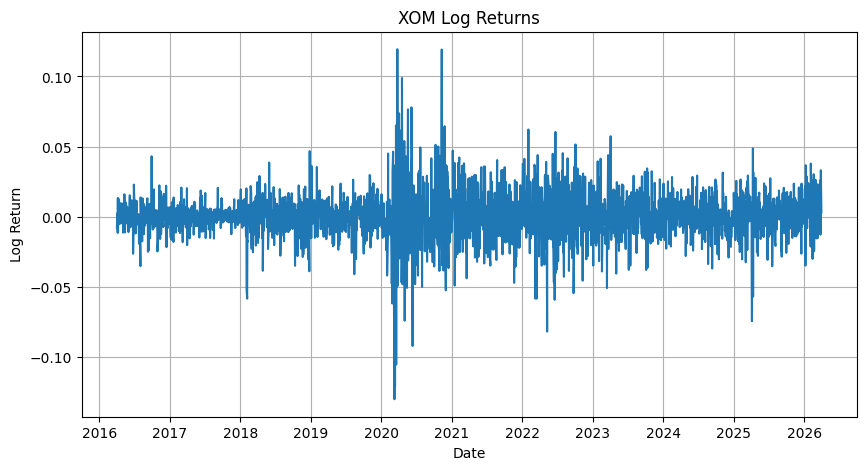

In [4]:
for ticker, df in stock_list:
    print(f"Ticker: {ticker}")
    df['Gross_SR'] = df['Close'] / df['Close'].shift(1)
    df['Net_SR'] = df['Gross_SR'] - 1
    df['LR'] = np.log(df['Gross_SR'])
    plt.figure(figsize=(10, 5))
    plt.plot(df['LR'])
    plt.title(f'{ticker} Log Returns')
    plt.xlabel('Date')
    plt.ylabel('Log Return')
    plt.grid()
    plt.savefig(f'./relazione/images/{ticker}_log_returns.png')
    plt.show()
    plt.close()

## Calcolo dei rendimenti composti annui e cumulati

Calcolo dei rendimenti composti annui e rendimenti cumulati per ogni titolo.

In [5]:
delta = end_date - start_date
t = delta/dt.timedelta(days=1)
for ticker, df in stock_list:
    df["Cum"] = np.cumprod(df["Gross_SR"])
    cagr = (df['Close'].iloc[-1] / df['Close'].iloc[0]) ** (365 / t) - 1
    print(f'{ticker} CAGR: {cagr:.2%}')
    display(df.tail())

GM CAGR: 11.03%


Price,Close,High,Low,Open,Volume,Gross_SR,Net_SR,LR,Cum
Date,,,,,,,,,
2026-03-24,76.570000,76.870003,74.769997,74.980003,7122200,1.011226,0.011226,0.011163,2.997666
2026-03-25,76.610001,78.290001,76.389999,77.900002,7190700,1.000522,0.000522,0.000522,2.999232
2026-03-26,75.599998,77.169998,74.910004,75.970001,8470900,0.986816,-0.013184,-0.013271,2.959691
2026-03-27,72.980003,75.260002,72.680000,75.209999,7563200,0.965344,-0.034656,-0.035271,2.857120
2026-03-30,72.760002,74.230003,72.419998,73.709999,7192300,0.996985,-0.003015,-0.003019,2.848507


MSFT CAGR: 22.12%


Price,Close,High,Low,Open,Volume,Gross_SR,Net_SR,LR,Cum
Date,,,,,,,,,
2026-03-24,371.934418,381.643400,371.046357,381.533622,42733600,0.973211,-0.026789,-0.027154,7.670136
2026-03-25,370.238129,376.245107,368.831172,376.105426,31181200,0.995439,-0.004561,-0.004571,7.635155
2026-03-26,365.179077,373.910167,364.400764,370.018602,36836600,0.986336,-0.013664,-0.013759,7.530825
2026-03-27,355.998932,361.666679,355.739515,361.117850,37883400,0.974861,-0.025139,-0.025460,7.341510
2026-03-30,358.184204,364.570366,355.510003,361.117853,44797000,1.006138,0.006138,0.006120,7.386575


NEE CAGR: 14.91%


...

Price,Close,High,Low,Open,Volume,Gross_SR,Net_SR,LR,Cum
Date,,,,,,,,,
2026-03-24,175.199997,176.220001,173.979996,174.830002,147667800,0.997495,-0.002505,-0.002508,200.865190
2026-03-25,178.679993,181.220001,176.850006,177.100006,162602100,1.019863,0.019863,0.019668,204.854973
2026-03-26,171.240005,176.509995,171.139999,176.070007,186152200,0.958361,-0.041639,-0.042530,196.325096
2026-03-27,167.520004,170.970001,167.009995,170.000000,196212700,0.978276,-0.021724,-0.021963,192.060149
2026-03-30,165.169998,169.449997,164.270004,168.779999,185627000,0.985972,-0.014028,-0.014128,189.365889


TSLA CAGR: 36.92%


Price,Close,High,Low,Open,Volume,Gross_SR,Net_SR,LR,Cum
Date,,,,,,,,,
2026-03-24,383.029999,387.480011,376.309998,376.559998,60004900,1.005724,0.005724,0.005708,25.005223
2026-03-25,385.950012,396.230011,385.010010,389.989990,55157300,1.007623,0.007623,0.007595,25.195849
2026-03-26,372.109985,384.440002,371.869995,381.600006,55522900,0.964140,-0.035860,-0.036518,24.292335
2026-03-27,361.829987,369.859985,359.470001,369.690002,62065700,0.972374,-0.027626,-0.028015,23.621229
2026-03-30,355.279999,367.290009,352.140015,365.859985,67954400,0.981898,-0.018102,-0.018268,23.193629


XOM CAGR: 12.23%


Price,Close,High,Low,Open,Volume,Gross_SR,Net_SR,LR,Cum
Date,,,,,,,,,
2026-03-24,164.265060,166.350894,160.162899,160.619804,26131800,1.026376,0.026376,0.026034,3.058614
2026-03-25,162.159348,163.887622,161.831570,162.765236,17192300,0.987181,-0.012819,-0.012902,3.019406
2026-03-26,164.314713,164.563027,160.967437,162.983750,18625200,1.013292,0.013292,0.013204,3.059538
2026-03-27,169.837234,170.075607,163.688963,164.463704,30338300,1.033609,0.033609,0.033057,3.162368
2026-03-30,170.313995,175.220694,169.896829,171.346977,29813500,1.002807,0.002807,0.002803,3.171245


## Grafici diagnostici

Creazione di grafici diagnostici a 3 sezioni (istogramma e kernel density, boxplot, qq-plot) per
ciascuna serie di rendimenti

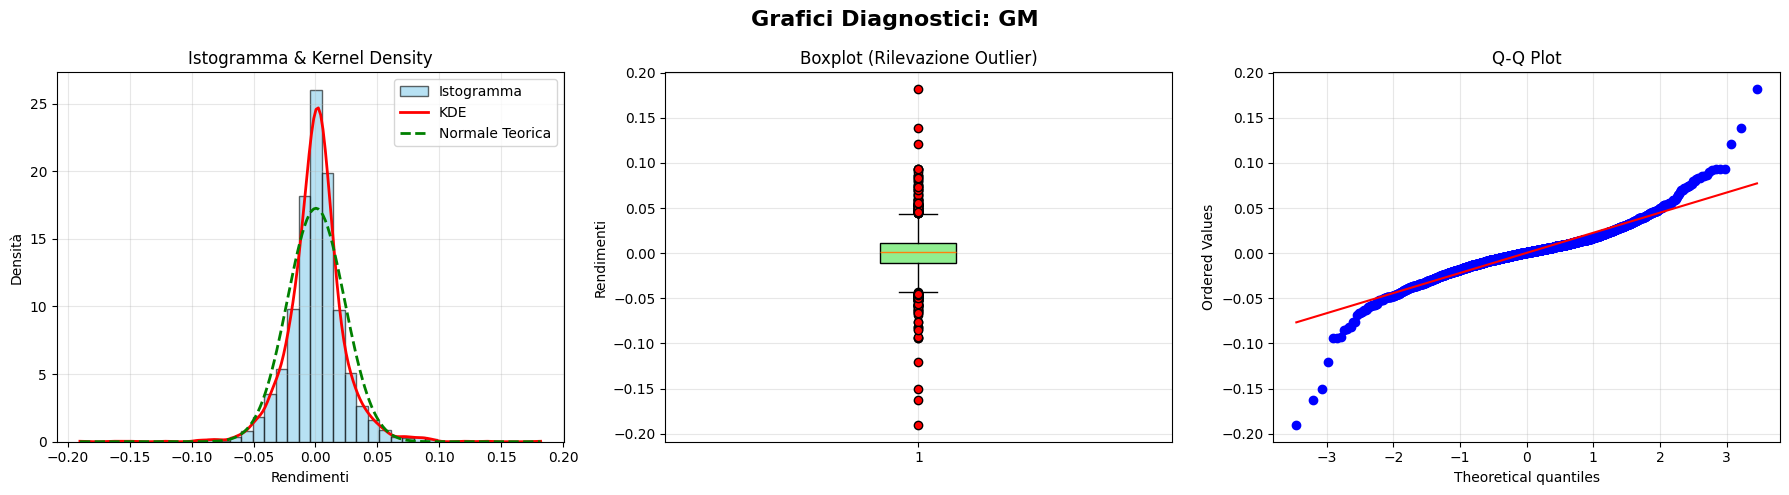

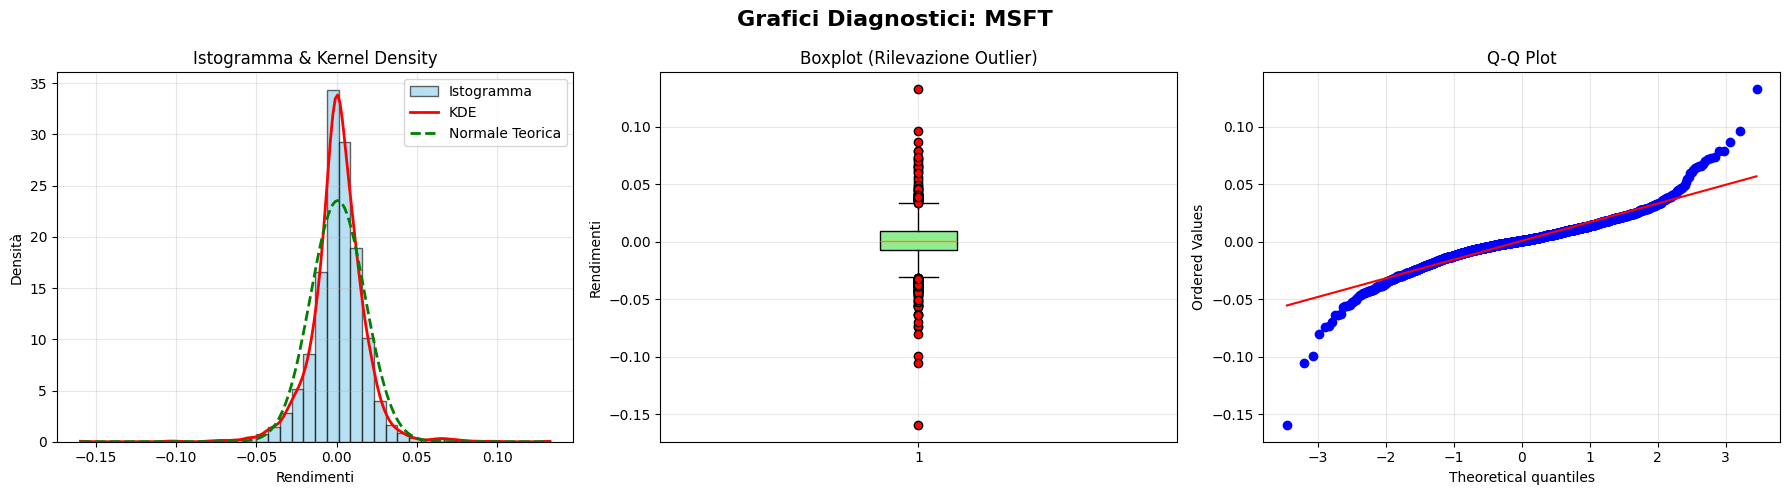

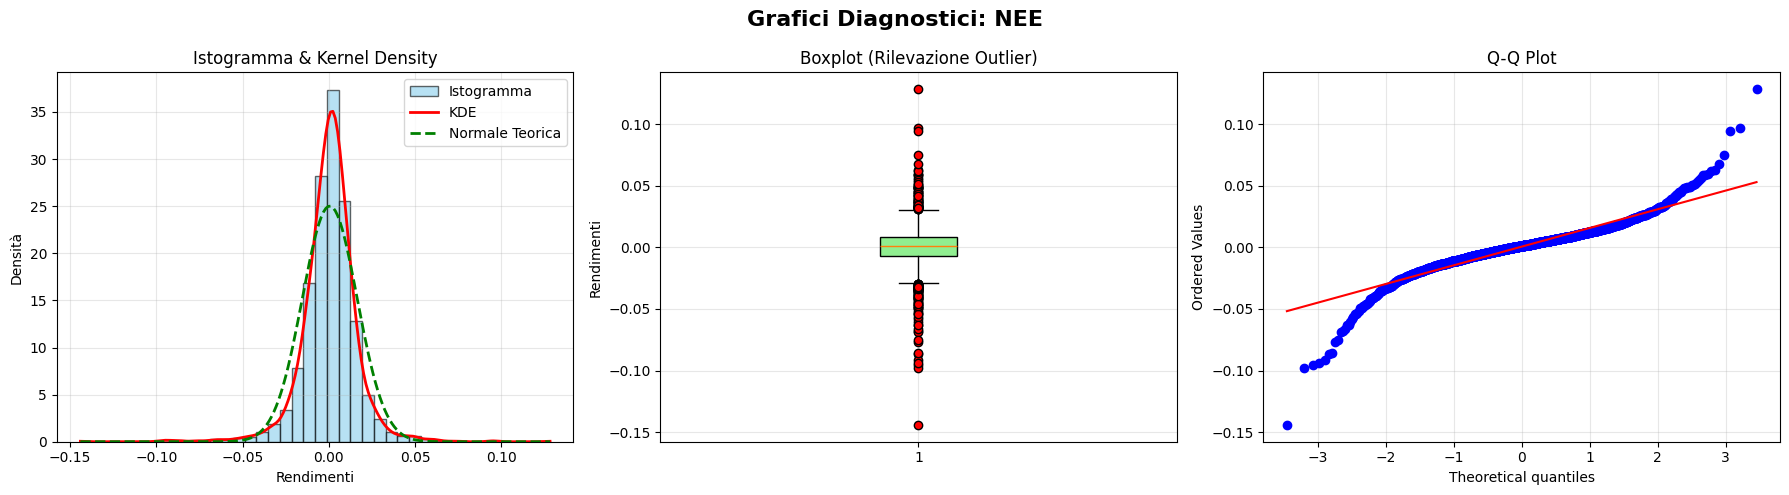

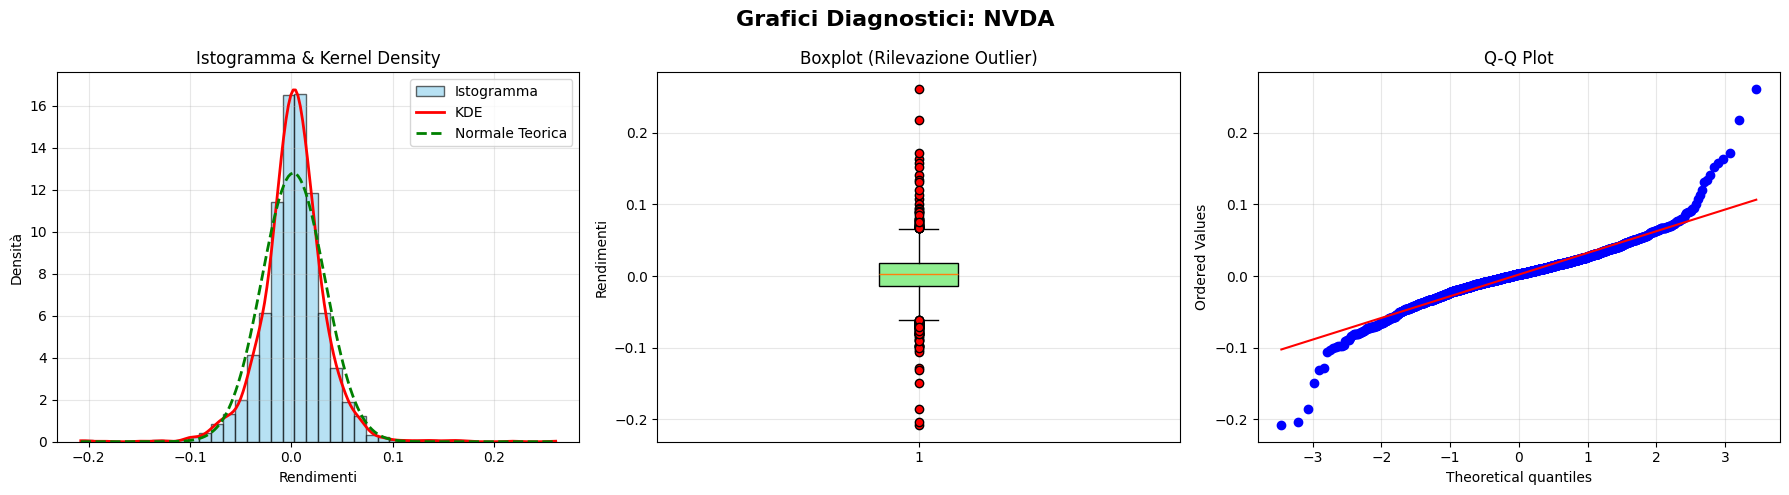

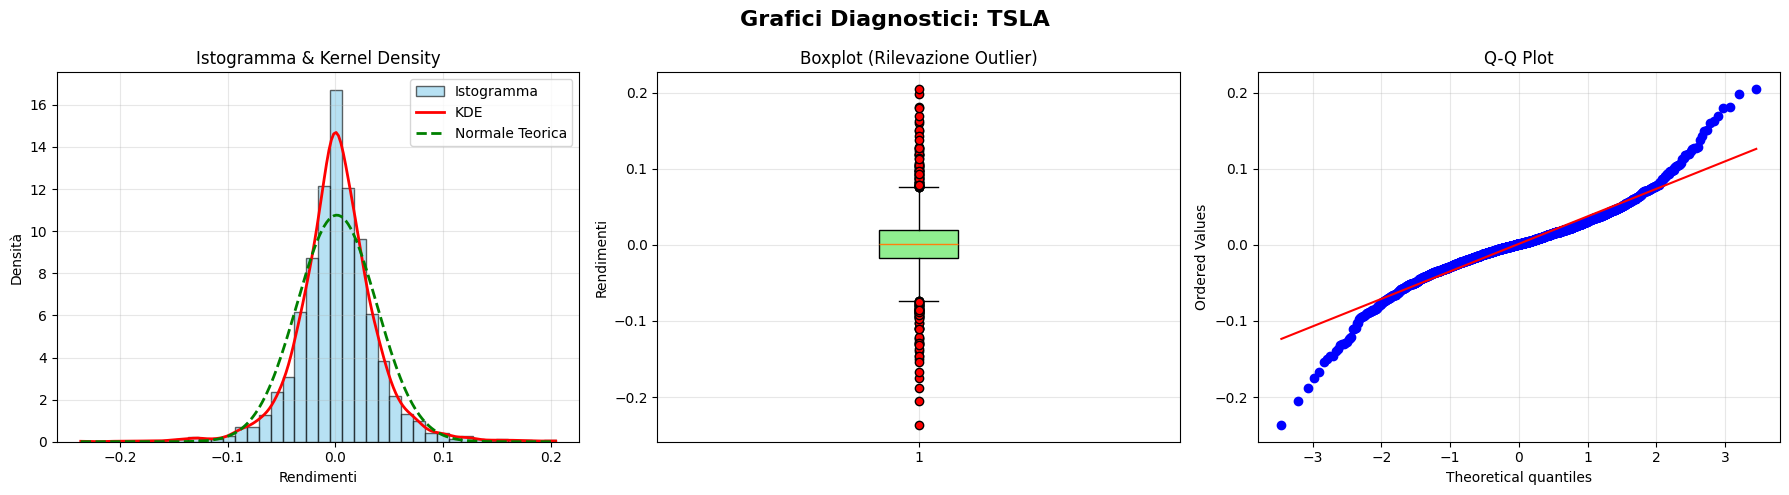

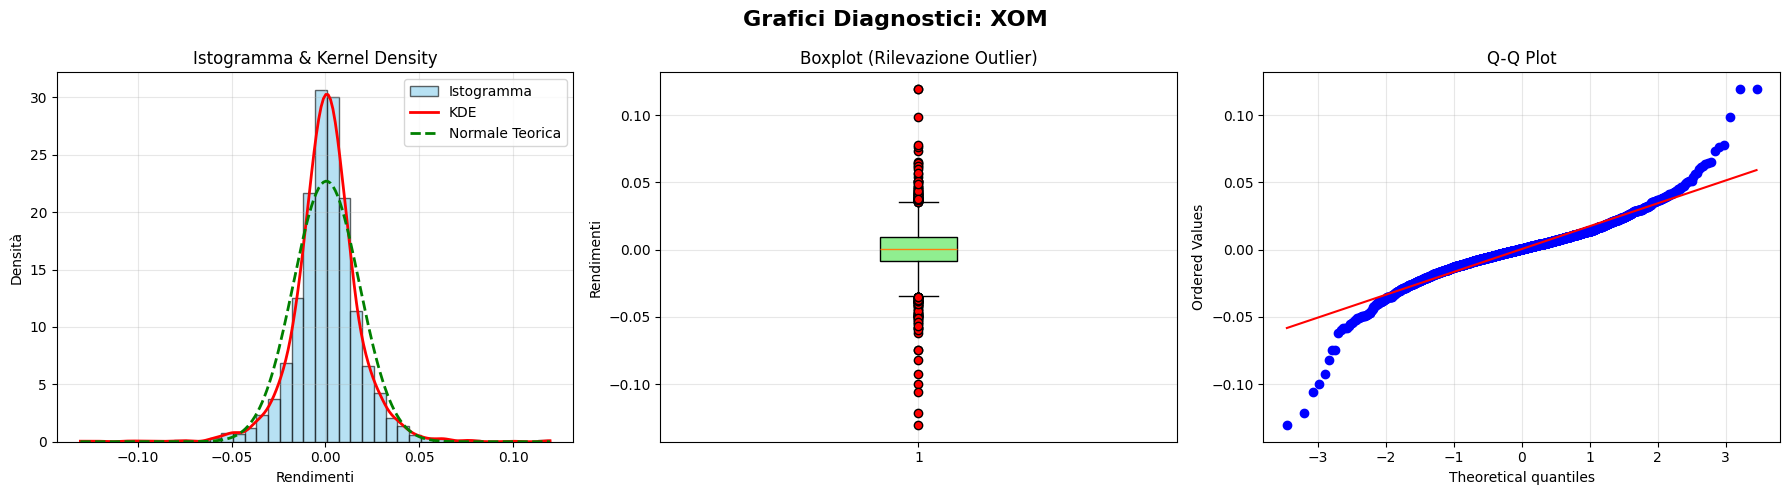

In [9]:
for ticker, df in stock_list:
    df_clean = df.dropna(subset=["LR"])
    # Creazione della figura con 3 sotto-grafici in linea
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(
        f"Grafici Diagnostici: {ticker}", fontsize=16, fontweight="bold"
    )

    # Sezione 1: Istogramma e Kernel Density (KDE)
    axes[0].hist(
        df_clean["LR"],
        bins=40,
        density=True,
        alpha=0.6,
        color="skyblue",
        edgecolor="black",
        label="Istogramma",
    )
    # Linea KDE
    kde = stats.gaussian_kde(df_clean["LR"])
    x_range = np.linspace(df_clean["LR"].min(), df_clean["LR"].max(), 200)
    axes[0].plot(x_range, kde(x_range), color="red", lw=2, label="KDE")
    # Linea Normale teorica per confronto
    mu, std = df_clean["LR"].mean(), df_clean["LR"].std()
    axes[0].plot(
        x_range,
        stats.norm.pdf(x_range, mu, std),
        color="green",
        linestyle="--",
        lw=2,
        label="Normale Teorica",
    )
    axes[0].set_title("Istogramma & Kernel Density")
    axes[0].set_xlabel("Rendimenti")
    axes[0].set_ylabel("Densità")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Sezione 2: Boxplot
    axes[1].boxplot(
        df_clean["LR"],
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor="lightgreen", color="black"),
        flierprops=dict(
            marker="o",
            markerfacecolor="red",
            markersize=6,
            linestyle="none",
        ),
    )
    axes[1].set_title("Boxplot (Rilevazione Outlier)")
    # axes[1].set_xticklabels(ticker)
    axes[1].set_ylabel("Rendimenti")
    axes[1].grid(True, alpha=0.3)

    # Sezione 3: Q-Q Plot
    stats.probplot(df_clean["LR"], dist="norm", plot=axes[2])
    axes[2].set_title("Q-Q Plot")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'./relazione/images/{ticker}_diagnostic_plots.png')
    plt.show()
    plt.close()